In [1]:
#from IPython.display import display, Latex

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec

In [2]:
import functions_spin_p as fy
from importlib import reload

reload(fy)

<module 'functions_spin_p' from '/mnt/c/Users/frnkl/Desktop/thesis_spin_caloritronics/tesis_model/site_dots_geyer/functions_spin_p.py'>

# Aplication:

### Example: Spin dependent Transmission plot

**Important:** If the location of any of the energies resonances is not match with the Transmission Plot (only in the y-axis) but it matches only with the x-axis. So, the Plot is correct, however, it is needed increase the numerical precision (by decreasing the step size in the energy_axis)

# Transmission behaviour: Site dots Geyer Model 

Geyer model is based on a normal sites within a helical geometry, the Hamiltonian condering the helical geometry for the site coupling.

To the Geyer model is added laterally a coupled double quantum dots chain where it is possible to have spin accumulation or not. *The parameters are described for a Tigh Binding Hamiltonian in the Second Quantization. And the remainded parameters are used into the solution for the Hamiltonian using Green Keldysh Functions.* 

This model have the following parameters: the Energy Site $(\epsilon^{\sigma}_{i})$ where, by assumption, there is spin degeneration of them $(\Delta=0\Rightarrow\,\epsilon^{\sigma}_{i} = \epsilon_{i})$. Additionally, we include the coupling constant $\omega$ and the Zeeman Geometric field $\vec{B}$, the bandwith due to leads contributions in the self energies $(\gamma_{L(R)})$ is parametrized by the polarization due to spin aligment of the leads $(p_{L(R)})$. Additionally, we have the Temperature of the entire system $(T)$, the hopping of the sites $(V)$ and the angular momentum $L$. 

# Toy Model:

**Fixed parameters**

$\epsilon^{0}_{1}\,=\,\epsilon^{0}_{2}\,=\,0\,meV$ 

$\epsilon^{1}_{1}\,=\epsilon^{0}_{1}\,=\,2\,meV$ 

$\gamma\,=\,1\,meV$

$B = -2$

$\lambda_2 = 0.5\,meV$

$E\,=\,[-6,6]$ $meV$

$L = 0, \pm 1$

**Variable Parameters**

$\omega\,=\,1\,meV$

$t\,=\,1\,meV$


In [3]:
#Site energies:
e_01 = 0 #meV
e_02 = 0 #meV
e_11 = 2 #meV
e_12 = 2 #meV

#Gamma i.e. width parameter
gamma = 1 #meV
print("The width is:",gamma,"meV")

# Helix geometric parameters:

lam_2 = 0.5 #meV

B = 0.5

#Energy axis

energy_axis = np.arange(-6, 6 + 0.01, 0.01) #meV
print("Energy axis is", energy_axis,"meV")

#Hopping parameters:
om = 1 #meV

t = 1 #meV

The width is: 1 meV
Energy axis is [-6.   -5.99 -5.98 ...  5.98  5.99  6.  ] meV


In [4]:
#Renormalized site energies array:
e_ren_1 = np.array([e_01,e_11, om])

e_ren_2 = np.array([e_02, e_12, om])

# print("The site (spin independent) energies are:", \
#       e_1," meV and",e_2," meV")

## Reference case:

We have $L=0$. Additionally, if $p_{L(R)}=0$ we have the same width (i.e. same particle lifetime) per spin channel! 

Additional, we include the different polarization configurations

In [5]:
# Angular momentum:

L = 1

e_ren_1_u = e_ren_1  #meV
e_ren_1_d = e_ren_1  #meV
e_ren_2_u = e_ren_2  #meV
e_ren_2_d = e_ren_2  #meV

site_energies = np.array([e_ren_1_u, e_ren_1_d , e_ren_2_u , e_ren_2_d], dtype = complex)
#print(site_energies)

Hamiltonian = np.array([[lam_2*L*B, -(1j)*lam_2*L*B,-t,0],[(1j)*lam_2*L*B, -lam_2*L*B, 0,-t],[-t,0,lam_2*L*B, -(1j)*lam_2*L*B],\
                        [0,-t, (1j)*lam_2*L*B, -lam_2*L*B]], dtype = complex)

print(Hamiltonian)

[[ 0.25+0.j    0.  -0.25j -1.  +0.j    0.  +0.j  ]
 [ 0.  +0.25j -0.25+0.j    0.  +0.j   -1.  +0.j  ]
 [-1.  +0.j    0.  +0.j    0.25+0.j    0.  -0.25j]
 [ 0.  +0.j   -1.  +0.j    0.  +0.25j -0.25+0.j  ]]


In [6]:
#POLARIZATION p_L = p_R = 0
p_L = 0
p_R = 0

#Transmission axis

transmission_u = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[0]
transmission_d = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[1]

/mnt/c/Users/frnkl/Desktop/thesis_spin_caloritronics/tesis_model/site_dots_geyer/functions_spin_p.py:100: ComplexWarning: Casting complex values to real discards the imaginary part
  transmission_axis_up[i] = green_matrix(energy_array[i], gamma_parameter, H, sites, polarization_left, polarization_right)[0]
/mnt/c/Users/frnkl/Desktop/thesis_spin_caloritronics/tesis_model/site_dots_geyer/functions_spin_p.py:101: ComplexWarning: Casting complex values to real discards the imaginary part
  transmission_axis_down[i] = green_matrix(energy_array[i], gamma_parameter, H, sites, polarization_left, polarization_right)[1]


In [7]:
#POLARIZATION UP-UP
p_L_1 = 0.5
p_R_1 = 0.5

#Transmission axis

transmission_u_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[0]
transmission_d_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[1]

In [8]:
#POLARIZATION UP-DOWN
p_L_2 = 0.5
p_R_2 = -0.5

#Transmission axis

transmission_u_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[0]
transmission_d_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[1]

/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:119: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


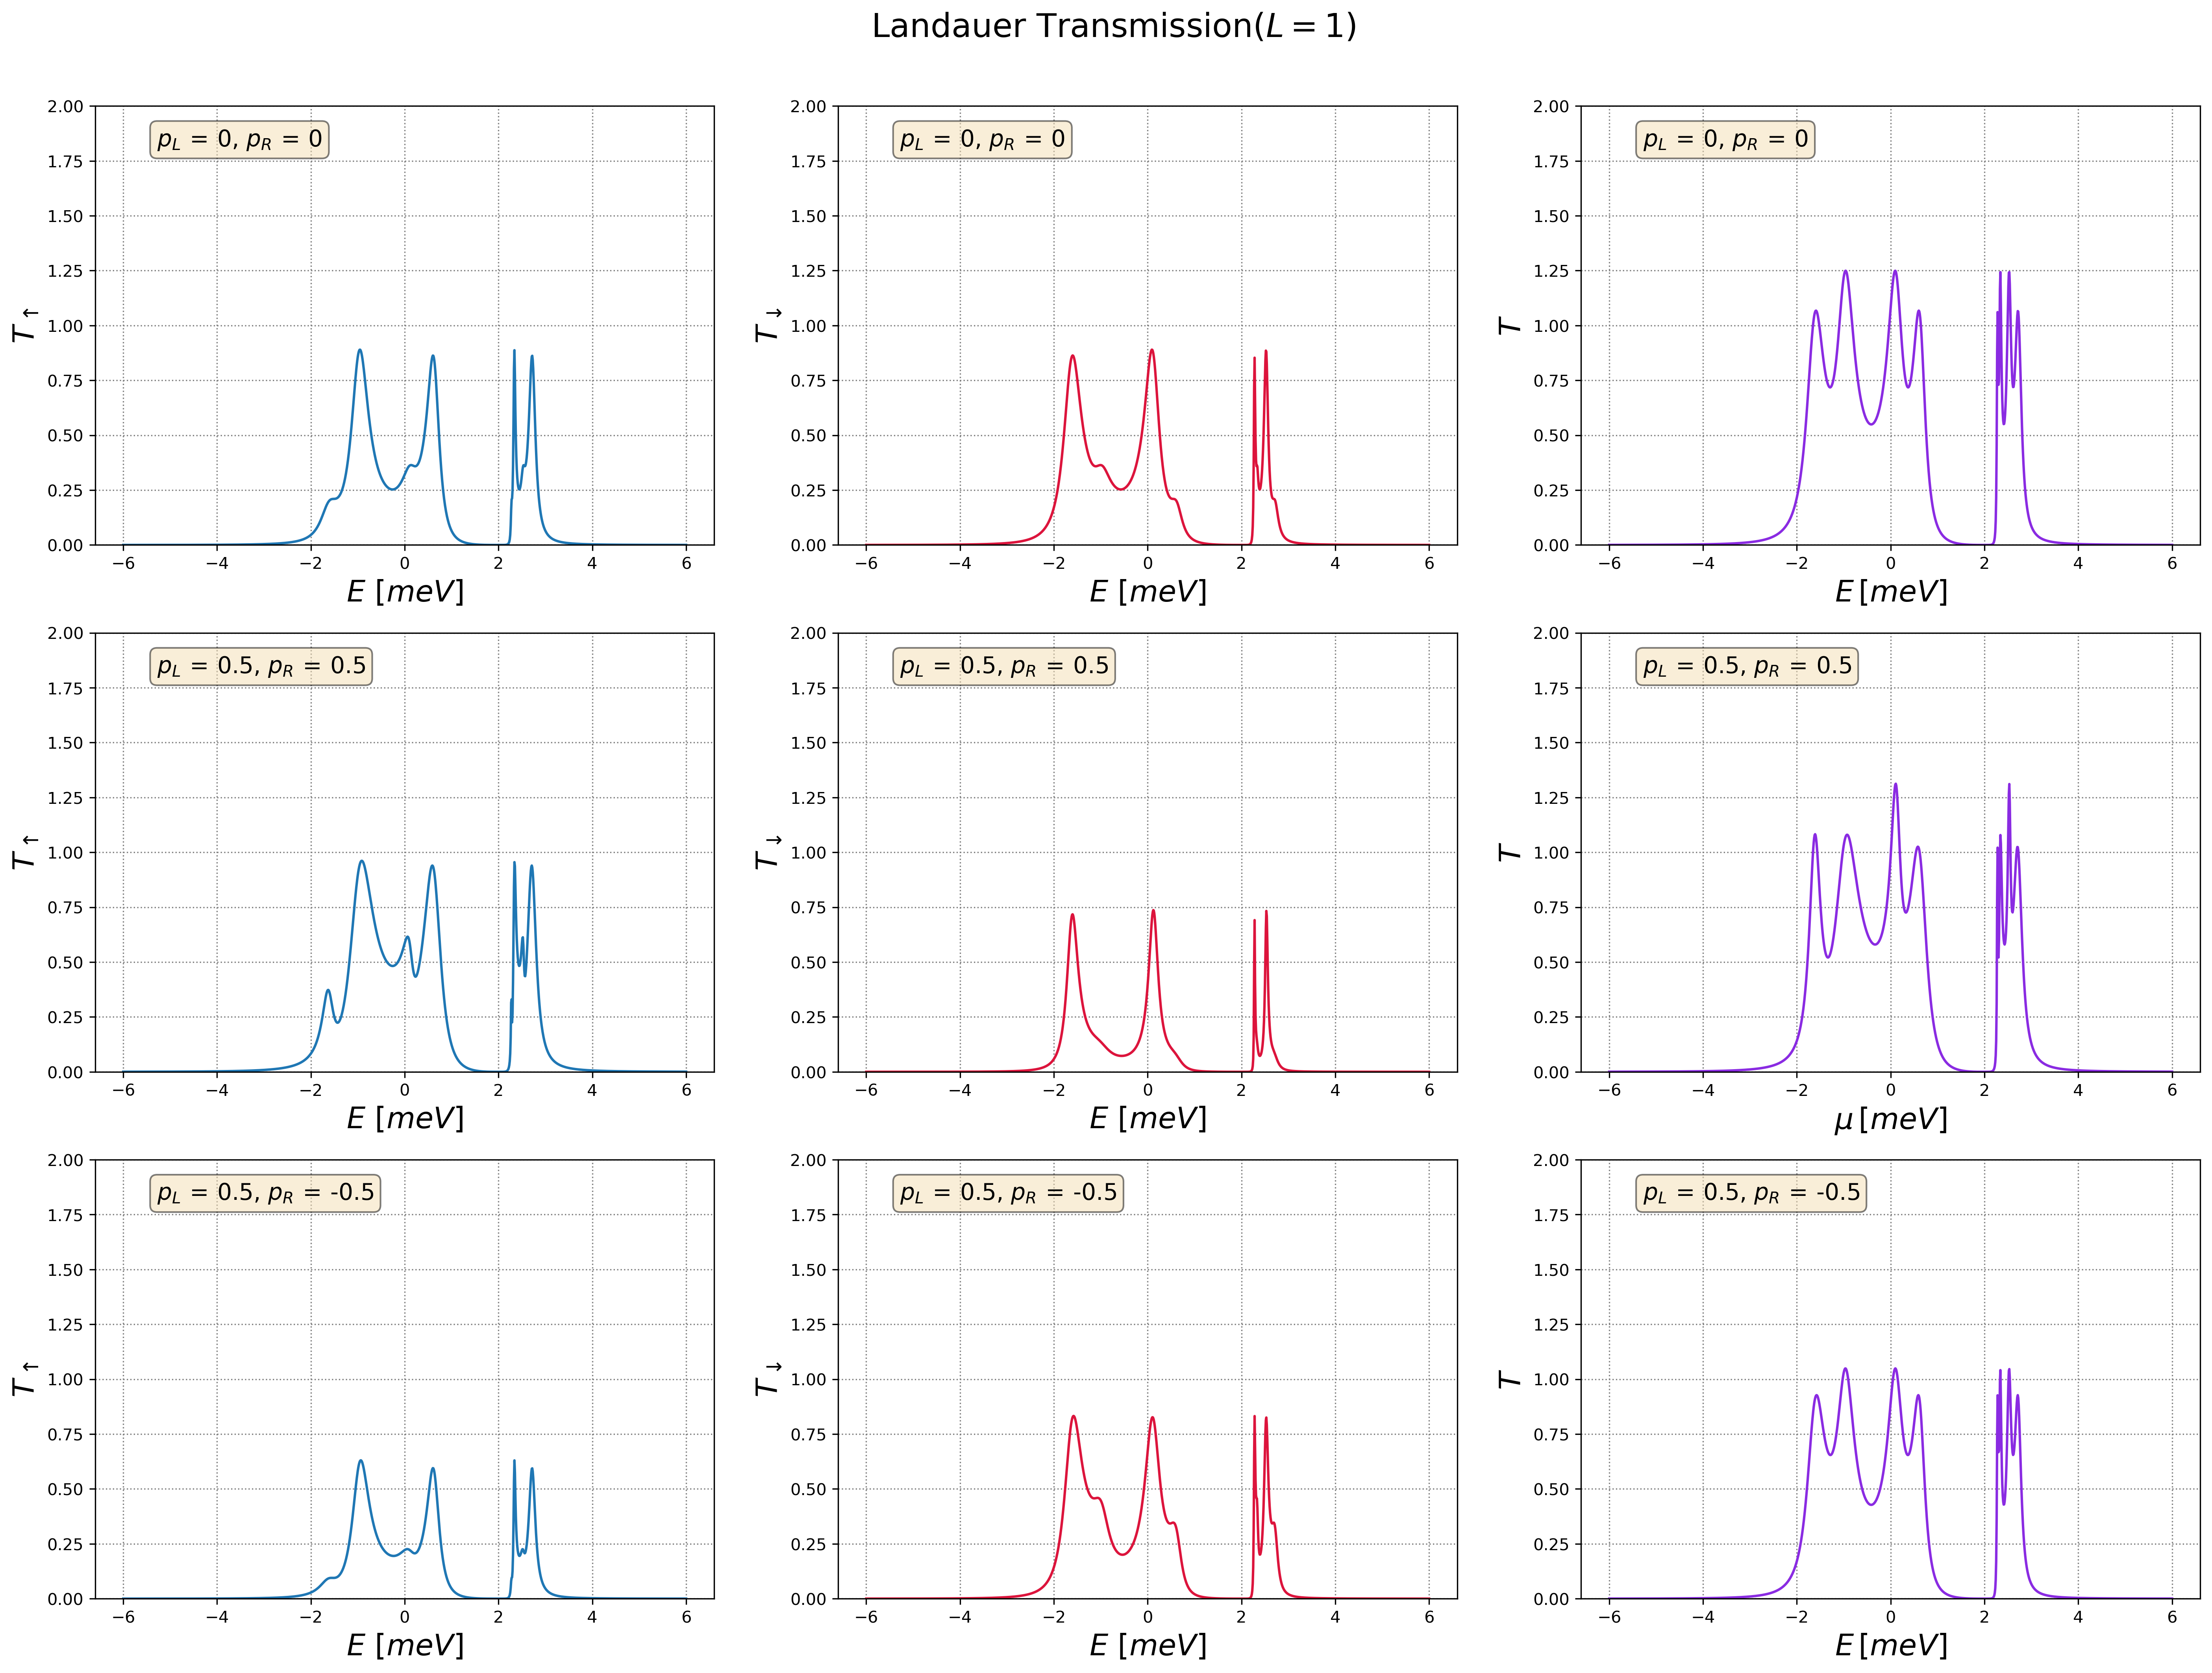

In [9]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(23, 16), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

#Set the grid for the subplots
gs = GridSpec(3, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 0])
ax8 = fig.add_subplot(gs[2, 1])
ax9 = fig.add_subplot(gs[2, 2])

# 0 - 0
# Transmission UP Plot
ax1.grid(linestyle=':', color='grey')
ax1.plot(energy_axis, transmission_u, "#1f77b4", linestyle="-")
ax1.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax1.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax1.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax1.legend( loc='upper right')

# Transmission DOWN Plot
ax2.grid(linestyle=':', color='grey')
ax2.plot(energy_axis, transmission_d, "#DC143C", linestyle="-")
ax2.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax2.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax2.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax2.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax2.legend( loc='upper right')

# Total Transmission Plot
ax3.grid(linestyle=':', color='grey')
ax3.plot(energy_axis, transmission_u + transmission_d, "#8A2BE2")
ax3.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax3.set_ylabel(r"$T$",fontsize=18)
ax3.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax3.legend( loc='upper right')  

# UP - UP

ax4.grid(linestyle=':', color='grey')
ax4.plot(energy_axis, transmission_u_1, "#1f77b4", linestyle="-")
ax4.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax4.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax4.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax4.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax4.legend( loc='upper right')

ax5.grid(linestyle=':', color='grey')
ax5.plot(energy_axis, transmission_d_1, "#DC143C", linestyle="-")
ax5.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax5.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax5.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax5.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax5.legend( loc='upper right')

ax6.grid(linestyle=':', color='grey')
ax6.plot(energy_axis, transmission_u_1 + transmission_d_1, "#8A2BE2")
ax6.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax6.set_ylabel(r"$T$",fontsize=18)
ax6.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax6.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax6.legend( loc='upper right')

# UP - UP

ax7.grid(linestyle=':', color='grey')
ax7.plot(energy_axis, transmission_u_2, "#1f77b4", linestyle="-")
ax7.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax7.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax7.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax7.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax7.legend( loc='upper right')

#Seebeck no spin accumulation Plot
ax8.grid(linestyle=':', color='grey')
ax8.plot(energy_axis, transmission_d_2, "#DC143C", linestyle="-")
ax8.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax8.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax8.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax8.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax8.legend( loc='upper right')

#Seebeck spin accumulation Plot:
ax9.grid(linestyle=':', color='grey')
ax9.plot(energy_axis, transmission_u_2 + transmission_d_2, "#8A2BE2")
ax9.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax9.set_ylabel(r"$T$",fontsize=18)
ax9.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax9.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax9.legend( loc='upper right')

# Stablish limits for the subplots
ax1.set_ylim(0, 2)  
ax2.set_ylim(0, 2)   
ax3.set_ylim(0, 2)  
ax4.set_ylim(0, 2)  
ax5.set_ylim(0, 2)   
ax6.set_ylim(0, 2)  
ax7.set_ylim(0, 2)  
ax8.set_ylim(0, 2)   
ax9.set_ylim(0, 2)  


# Ajustar el diseño y mostrar los subplots
plt.suptitle("Landauer Transmission"+r"($L=$"+str(L)+")", fontsize=20, y=0.95)

# Ajustar el espacio superior
plt.subplots_adjust(top=0.9)

#plt.tight_layout()

plt.show()

#fig.savefig('Reference.jpg')